# Hierarchical clustering
- used for Exploatory data analysis

In [33]:
# -------------------------------------------
# Hierarchical Clustering on Iris Dataset
# -------------------------------------------

from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

In [40]:
# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for clarity
df = pd.DataFrame(X, columns=feature_names)
df['actual_label'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   actual_label  
0             0  
1             0  
2             0  
3             0  
4             0  


In [41]:
# 2. Standardize the data (VERY IMPORTANT for HC). TODO Remove the column actual label
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled[:10])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443  -1.22474487]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443  -1.22474487]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443  -1.22474487]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443  -1.22474487]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443  -1.22474487]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993 -1.22474487]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211 -1.22474487]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443  -1.22474487]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443  -1.22474487]
 [-1.14301691  0.09821729 -1.2833891  -1.44707648 -1.22474487]]


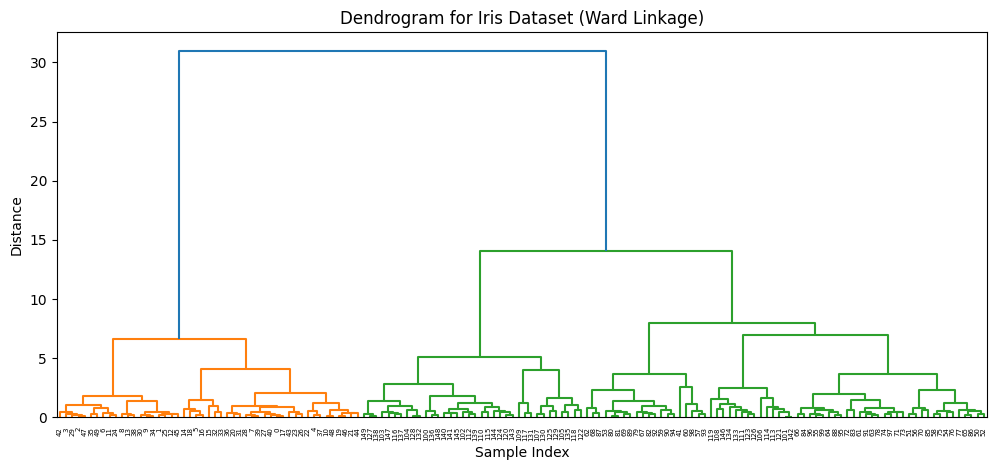

In [42]:

# 3. Perform hierarchical clustering (Ward linkage)
Z = linkage(X_scaled, method='ward')

# 4. Plot dendrogram
plt.figure(figsize=(12, 5))
plt.title("Dendrogram for Iris Dataset (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(Z)
plt.show()

# Look for long vertical lines not crossed by any horizontal line.
# The number of vertical branches below the cut is the number of clusters.
# For the Iris dataset, you typically see 3 large branches → 3 natural clusters.

In [48]:
# 4. Predict clusters (k = 3)
clusters = fcluster(Z, t=3, criterion='maxclust')
df['predicted_cluster'] = clusters
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   actual_label  predicted_cluster  
0             0                  1  
1             0                  1  
2             0                  1  
3             0                  1  
4             0                  1  


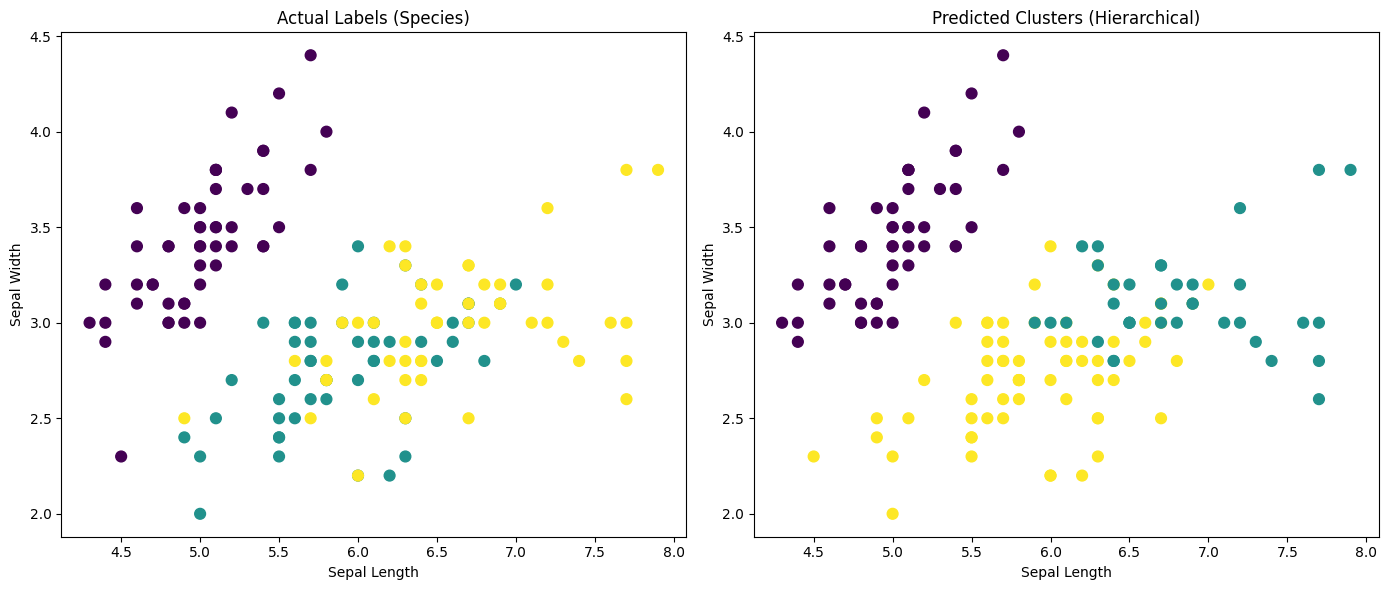

In [49]:

# 5. Scatter plots: Actual vs Predicted
plt.figure(figsize=(14, 6))

# ----- LEFT PLOT (Actual Labels) -----
plt.subplot(1, 2, 1)
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['actual_label'], s=60)
plt.title("Actual Labels (Species)")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

# ----- RIGHT PLOT (Predicted Clusters) -----
plt.subplot(1, 2, 2)
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['predicted_cluster'], s=60)
plt.title("Predicted Clusters (Hierarchical)")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.tight_layout()
plt.show()
